# AP 155 Lab Exercise
---
## Exercise 2: Numbers, Subtractive Cancellation

_Instructions_: 
- **Report figure:** Two Figures (see *Problem 2: Rewriting functions...*) - Plot f(x) vs. x using the manual evaluation (the one with catastrophic cancellation) vs. the "better function". In each figure, show the area where the catastrophic cancellation occurs. There are two functions discussed in the exercise, hence two figures (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)
- **Report discussion:** Two Questions: 
    - (See Problem 1) Why do the "bad" and "good" formulas of the roots give out the values they do (what makes "good" good)? What led to the difference between the obtained values?
    - (See Problem 2) In each of the two functions discussed, for which values of x does the catastrophic cancellation occur (include here what the expected values were)? How were the catastrophic cancellations remedied? 
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Ricerra, Myke Lawrence
- _Student No._: 2024-07203
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

![Problem 2 First Function](./figures/1_problem2.png)
- The raw evaluation of $f(x) = \sqrt{x^2+x}-x$ (w/ catastrophic cancellation) drops to 0 for $x > 10^{15}$, whereas the one multiplied with its conjugate $g(x) = \frac{x}{\sqrt{x^2+x}+x}$ preserves the true limit of 0.5.

![Problem 2 Second Function](./figures/2_problem2.png)
- The raw evaluation of $f(x) = \frac{e^x-1}{x}$ (w/ catastrophic cancellation) starts to deviate for $0< x < 10^{-12}$, whereas the equivalent $h(x) = \frac{e^x-1}{\ln(e^x)}$ preserves the true limit of 1.

### Bonus:

![Problem 2 First Function](./figures/1_problem2(bonus).png)
- Evaluation of $f(x) = \sqrt{x^2+x}-x$ across floating-point precisions shows catastrophic cancellation occurring earlier as bit-width decreases: float16 breaks around $x > 10^2$, float32 around $x > 10^7$, and float64 around $x > 10^{15}$, whereas float128 maintains the true limit of 0.5 (based on the domain).

![Problem 2 Second Function](./figures/2_problem2(bonus).png)
- Evaluation of $f(x) = \frac{e^x - 1}{x}$ across floating-point precisions shows catastrophic cancellation near $x \to 0$ occurring sooner as bit-width decreases: float16 breaks around $x < 10^{-3}$, for float32 its $x < 10^{-7}$, and for float64 its $x < 10^{-15}$, whereas float128 maintains the true limit of 1 (based on the domain).

### Report discussion

Catastrophic cancellation happens when we subtract two nearly equal floating-point numbers. The representation error of these numbers immensely affects the resulting difference between them. This phenomenon is seen in the first problem, where it degrades accuracy in the quadratic formula. When $b^2 \gg 4ac$, evaluating $-b + \sqrt{b^2 - 4ac}$ produces a result that is far from its theoretical value. To resolve this, we first compute the root without loss of precision, then apply the identity $x_+ x_- = \frac{c}{a}$ to derive the other root (which has catastrophic cancellation if computed directly). Moreover, similar cancellation errors emerge in the expressions $\frac{e^x - 1}{x}$ near $x \to 0$ and $\sqrt{x^2 + x} - x$ as $x \to \infty$. These errors are bypassed by finding an equivalent expressions free from catastrophic cancellation without violating mathematics. Ultimately, the results show that the behavior of the reformulated graphs preserves maximum precision across extreme input ranges compared to their raw evaluation.

## Section 2 (Problems and Code)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math as mt

### Problem 1: Quadratic Equation (Gezerlis Problem 2.6)
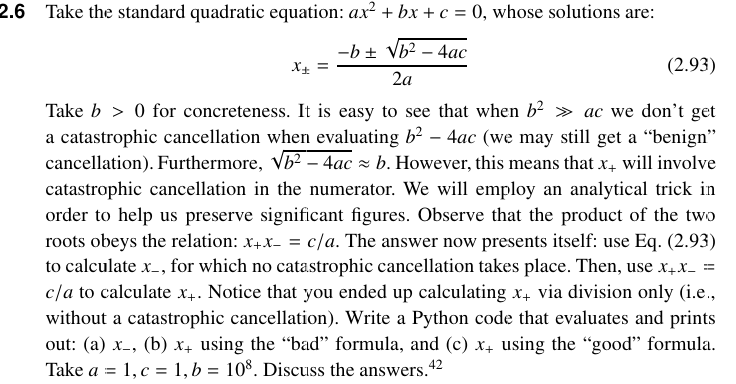

In [2]:
def disc(a, b, c):
    disc = (b**2) - 4*a*c
    return disc

def minusroot(a, b, c):
    if disc(a, b, c) >= 0:
        x = (-b - mt.sqrt(disc(a, b, c))) / (2*a)
        return x
    else: 
        print("No real roots")
        return

def badplusroot(a, b, c):
    if disc(a, b, c) >= 0:
        x = (-b + mt.sqrt(disc(a, b, c))) / (2*a)
        return x
    else:
        print("No real roots")
        return

def goodplusroot(a, b, c):
    x = c/(a*minusroot(a, b, c))
    return x


root1 = minusroot(1, 1e8, 1)     #theoretical value is -1e8
root2 = badplusroot(1, 1e8, 1)   #theoretical value is -1e-8
root2_alt = goodplusroot(1, 1e8, 1)

print(f"When a=1, b=1e8, and c=1, using the 'bad' formula, the roots are:\nx(-) = {root1} \nx(+) = {root2} \nUsing the 'good formula' the value of x(+) is,\nx(+) = {root2_alt}")

When a=1, b=1e8, and c=1, using the 'bad' formula, the roots are:
x(-) = -100000000.0 
x(+) = -7.450580596923828e-09 
Using the 'good formula' the value of x(+) is,
x(+) = -1e-08


#### Problem 1 code summary

The code shows the effect of catastrophic cancellation when solving for the roots of a quadratic equation. The 'badplusroot' function loses its precision because we are subtracting two very large and almost equal numbers. The goodplusroot function, on the other hand, retains precision since it takes advantage of the 'minusroot' function (where no catastrophic cancellation occurs) and the $x_+x_-=c/a$ identity (free of catastrophic cancellation) to solve for the very small exact value of the 'plus' root.

---


### Problem 2: Rewriting Functions to avoid subtractive cancellation

### Part 1: $ f(x) = \sqrt{x^2 + x} - x $

Consider the function 
$$ f(x) = \sqrt{x^2 + x} - x $$

- For which values of x does the catastrophic cancellation occur?
    - The catastrophic cancellation is expected to occur when $x$ is extremely large. As a result $x^2>>x$, which makes $\sqrt{x^2 + x}\approx x\rightarrow f(x)\approx 0$.
- How can we rewrite the function to avoid catastrophic cancellation?
  $$\sqrt{x^2+x}-x=\left(\sqrt{x^2+x}-x\right)\left(\frac{\sqrt{x^2+x}+x}{\sqrt{x^2+x}+x}\right)=\frac{x}{\sqrt{x^2+x}+x}:=g(x)$$
    - By multiplying using the conjugate, we can eliminate the subtraction part which causes the catastrophic cancellation.
- [FIGURE] Plot f(x) vs. x using the manual evaluation vs. the rewritten function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)

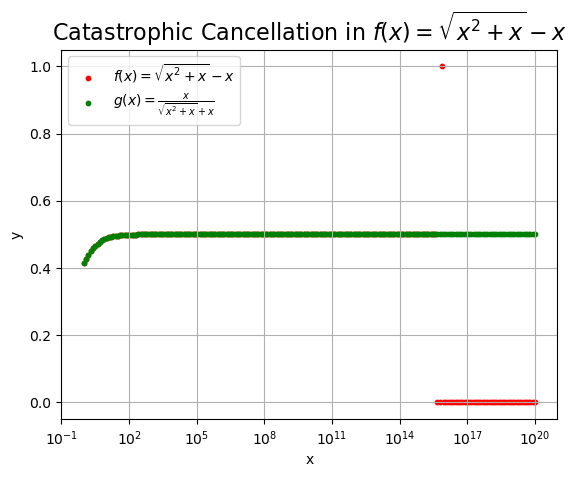

In [3]:
def f(x):
    f = np.sqrt((x*x)+x)-x
    return f

def f_better(x):
    f = x/(np.sqrt((x*x)+x)+x)
    return f

x1 = np.logspace(0, 20, 200)
y1 = f(x1)

x2 = np.logspace(0, 20, 200)
y2 = f_better(x2)

plt.title(r"Catastrophic Cancellation in $f(x)=\sqrt{x^2+x}-x$", fontsize=16)
plt.scatter(x1, y1, s=10, color="red", label=r"$f(x)= \sqrt{x^2 + x} - x$")
plt.scatter(x2, y2, s=10, color="green", label=r"$g(x) = \frac{x}{\sqrt{x^2+x}+x}$")
plt.xlabel("x")
plt.ylabel("y")
plt.xscale('log')
plt.legend(loc="upper left")
plt.grid(True)

plt.show() #theoretically, y->0.5, as x->inf

/tmp/ipykernel_8697/3589885312.py:2: RuntimeWarning: overflow encountered in multiply
  f = np.sqrt((x*x)+x)-x
/tmp/ipykernel_8697/3589885312.py:16: RuntimeWarning: overflow encountered in cast
  x_plt = x.astype(pt)
/tmp/ipykernel_8697/3589885312.py:2: RuntimeWarning: invalid value encountered in subtract
  f = np.sqrt((x*x)+x)-x


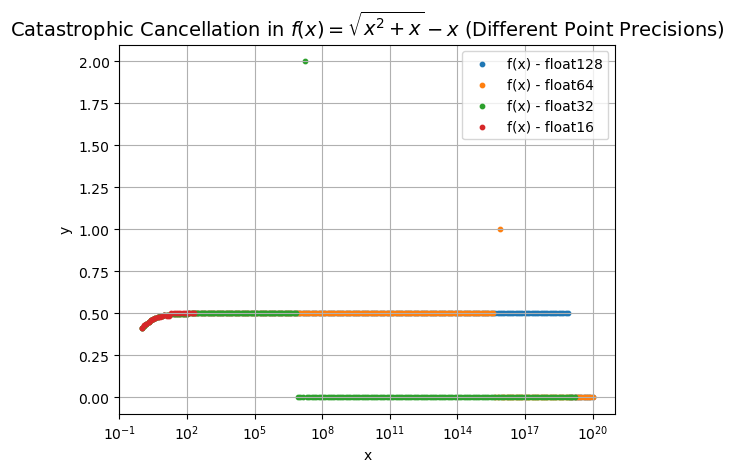

In [4]:
def f(x):
    f = np.sqrt((x*x)+x)-x
    return f

x = np.logspace(0, 20, 200)

ptpres = {
    "float128": np.float128,
    "float64": np.float64,
    "float32": np.float32,
    "float16": np.float16,
}

plt.title(r"Catastrophic Cancellation in $f(x)=\sqrt{x^2+x}-x$ (Different Point Precisions)", fontsize=14)
for label, pt in ptpres.items():
    x_plt = x.astype(pt)
    y_plt = f(x_plt)
    plt.scatter(x_plt, y_plt, s=10, label=f"f(x) - {label}")
plt.xlabel("x")
plt.ylabel("y")
plt.xscale('log')
plt.legend(loc="upper right")
plt.grid(True)

plt.show()

#### Part 2: $ f(x) = \frac{e^x - 1}{x}$

Consider the function 
$$ f(x) = \frac{e^x - 1}{x}$$

- For which values of x does the catastrophic cancellation occur?
    - The catastrophic cancellation is expected to occur around small values near $x=0$. 
- How can we resolve the catastrophic cancellation?
    - Using $$\frac{e^x-1}{x}=\frac{e^x-1}{\ln(e^x)}:=h(x),$$ we can resolve the catastrophic cancelletion since both numerator and denominator now carries the same rounding error, hence a much accurate plot.
- [FIGURE] Plot the f(x) vs. x using the manual evaluation vs. the numpy special function. In the figure, show the area where the catastrophic cancellation occurs. (Bonus: also compare with different hardware floating-point precisions: 16/32/64/128-bit)



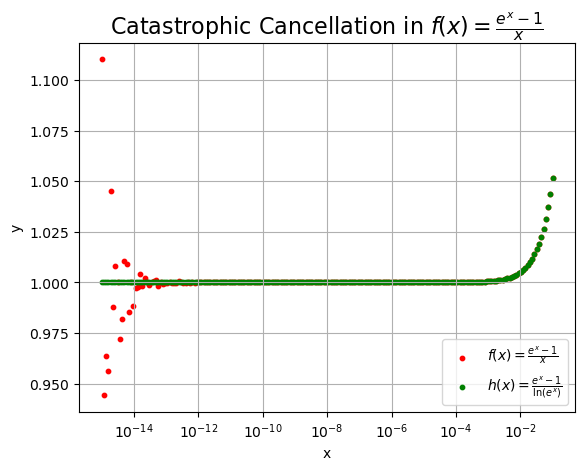

In [5]:
def f(x):
    f = (np.exp(x)-1)/x
    return f

def f_better(x):
    f = (np.exp(x)-1)/(np.log(np.exp(x)))
    return f

x1 = np.logspace(-15, -1, 200)
y1 = f(x1)

x2 = np.logspace(-15, -1, 200)
y2 = f_better(x2)

plt.title(r"Catastrophic Cancellation in $f(x)=\frac{e^x-1}{x}$", fontsize=16)
plt.scatter(x1, y1, s=10, color="red", label=r"$f(x)=\frac{e^x-1}{x}$")
plt.scatter(x2, y2, s=10, color="green", label=r"$h(x)=\frac{e^x-1}{\ln(e^x)}$")
plt.xlabel("x")
plt.ylabel("y")
plt.xscale("log")
plt.legend(loc="lower right")
plt.grid(True)

plt.show() #theoretically, y->1 as x->0

/tmp/ipykernel_8697/2459350676.py:2: RuntimeWarning: invalid value encountered in divide
  f = (np.exp(x)-1)/x


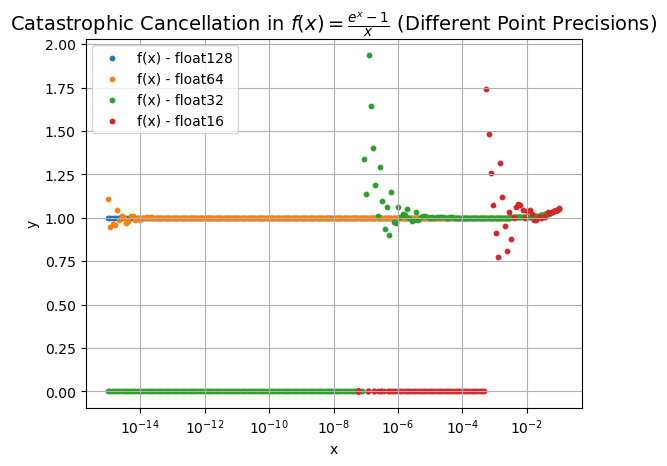

In [6]:
def f(x):
    f = (np.exp(x)-1)/x
    return f

x = np.logspace(-15, -1, 200)

ptpres = {
    "float128": np.float128,
    "float64": np.float64,
    "float32": np.float32,
    "float16": np.float16,
}

plt.title(r"Catastrophic Cancellation in $f(x) = \frac{e^x - 1}{x}$ (Different Point Precisions)", fontsize=14)
for label, pt in ptpres.items():
    x_plt = x.astype(pt)
    y_plt = f(x_plt)
    plt.scatter(x_plt, y_plt, s=10, label=f"f(x) - {label}")
plt.xlabel("x")
plt.ylabel("y")
plt.xscale("log")
plt.legend(loc="upper left")
plt.grid(True)

plt.show()

#### Problem 2 code summary

The code compares plots of the original function (wuth catastrophic cancellation) against an equivalent function designed to bypass the error. These errors are most prominent at extreme values (very small or very large numbers). Additionally, comparing floating-point precisions shows the expected behavior: lower precision fails first, while higher precision much later as we approach the problematic value.

---

## Section 3 (Notes)

### Floating-point representation
Python uses 64-bit float by default for any number you type in with a decimal point. Different floating point precision can be used at a lower level, which we can go around by using [Numpy dtypes](https://numpy.org/doc/stable/reference/arrays.dtypes.html). 

Useful links:
* [(Goldberg, 1991) *What every computer scientist should know about floating-point arithmetic*](https://dl.acm.org/doi/10.1145/103162.103163)
* [Wikipedia - Floating-point arithmetic](https://en.wikipedia.org/wiki/Floating-point_arithmetic)
* [Data types - NumPy](https://numpy.org/doc/stable/user/basics.types.html)
* [decimal — Decimal fixed-point and floating-point arithmetic](https://docs.python.org/3/library/decimal.html)
* [fractions — Rational numbers](https://docs.python.org/3/library/fractions.html)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

from decimal import Decimal
from fractions import Fraction

# Classic floating point quirks example
print(0.1 + 0.2)

# How about increasing precision?
print(np.float128(0.1) + np.float128(0.2))

# How bad is decreasing precision?
print(np.float16(0.1) + np.float16(0.2))

# Closest we could get to fixed-point arithmetic: decimal
print(Decimal(0.1) + Decimal(0.2))

# How about using an explicit Fraction object type?
print(float(Fraction(1, 10) + Fraction(1, 5)))

0.30000000000000004
0.30000000000000001665
0.2998
0.3000000000000000166533453694
0.3
